## Slides RL 5 - Training GRPO


In [1]:
BLUE="#2ca3dd"
YELLOW="#ffd35a"
RED='#ec2027'
CHILL_BROWN="#948979"

In [2]:
import gymnasium as gym
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from tqdm import tqdm
import json
from matplotlib.path import Path
from matplotlib.markers import MarkerStyle
from matplotlib.patches import FancyBboxPatch, Circle
# from pathlib import Path
import os

import matplotlib.colors as mcolors
cmap = mcolors.LinearSegmentedColormap.from_list("blue_gold", [BLUE, YELLOW], N=256)

Matplotlib is building the font cache; this may take a moment.


In [3]:
def style_ax(ax, color=CHILL_BROWN):
    ax.spines[:].set_color(color)
    ax.tick_params(colors=color, which='both')
    ax.xaxis.label.set_color(color)
    ax.yaxis.label.set_color(color)
    ax.title.set_color(color)


def arrow_path(direction=1, shaft_w=0.28, head_w=0.9, head_len=0.9, total_len=2.0):
    hl = head_len; sw = shaft_w/2; hw = head_w/2; L = total_len/2
    verts = np.array([
        (-L,  sw), (L-hl,  sw), (L-hl,  hw), (L, 0),
        (L-hl, -hw), (L-hl, -sw), (-L, -sw), (-L, sw),
    ]) * direction   # direction=-1 mirrors -> left arrow
    codes = [Path.MOVETO] + [Path.LINETO]*6 + [Path.CLOSEPOLY]
    return Path(verts, codes)

In [4]:
HACKIN_DIR = '/Volumes/hot_1/Stephencwelch Dropbox/welch_labs/rl_1/hackin'
# HACKIN_DIR = '/Users/stephen/Library/CloudStorage/Dropbox-Stephencwelch/welch_labs/rl_1/hackin'

In [5]:
VEL_SCALE = 10   # divide all velocities by 10 -> feature scales comparable, ~isotropic parameter space

In [6]:
CART_W, CART_H, POLE_LEN, WHEEL_R = 0.5, 0.26, 1.0, 0.07

def draw_cartpole(ax, cart_x, pole_theta, action=None):
    ax.set_xlim(-2.4, 2.4); ax.set_ylim(-0.55, 1.75)
    ax.set_aspect('equal'); ax.axis('off')
    ax.plot([-2.4, 2.4], [0, 0], color=CHILL_BROWN, lw=1.5, zorder=1)   # track
    cart_y = WHEEL_R*2
    for dx in (-CART_W*0.3, CART_W*0.3):
        ax.add_patch(Circle((cart_x+dx, WHEEL_R), WHEEL_R, color=CHILL_BROWN, zorder=3))
    ax.add_patch(FancyBboxPatch((cart_x-CART_W/2, cart_y), CART_W, CART_H,
                 boxstyle="round,pad=0.02,rounding_size=0.05",
                 fc='#3a3a3a', ec=CHILL_BROWN, lw=1.5, zorder=4))
    px, py = cart_x, cart_y + CART_H
    ax.plot([px, px + POLE_LEN*np.sin(pole_theta)],
            [py, py + POLE_LEN*np.cos(pole_theta)],
            color='w', lw=6, solid_capstyle='round', zorder=5)
    ax.add_patch(Circle((px, py), 0.045, color=CHILL_BROWN, zorder=6))
    if action is not None:   # action arrow under the cart, your color convention
        ax.scatter([cart_x], [-0.32],
                   marker=(RIGHT_ARROW if action==1 else LEFT_ARROW), s=420,
                   color=(YELLOW if action==1 else BLUE), linewidths=0, zorder=5)

In [7]:
RIGHT_ARROW = MarkerStyle(arrow_path(+1))
LEFT_ARROW  = MarkerStyle(arrow_path(-1))

ANG_LIM = (-13, 13) #Ok I want this to be in degrees!
VEL_LIM = (-17, 17)   # angvel data is pre-divided by VEL_SCALE=10

## 0. Some setup and baselines

In [8]:
class Pi(nn.Module):
    """Two-parameter policy: logit = theta1 * pole_angle + theta2 * pole_ang_velocity.

    P(right) = sigmoid(logit). Returns [P(left), P(right)] with shape (2,) or (T, 2),
    so the REINFORCE loop below is unchanged from the neural net version.
    """
    def __init__(self):
        super().__init__()
        self.theta = nn.Parameter(torch.zeros(2))  # [theta1, theta2] -> uniform random policy at init

    def forward(self, x):
        feats = x[..., 2:4]                # state indices 2, 3: pole angle, pole angular velocity
        logit = feats @ self.theta         # scalar or (T,)
        p_right = torch.sigmoid(logit)
        return torch.stack([1.0 - p_right, p_right], dim=-1)

In [9]:
# # This might be cleaner scaling wise, but I have a good amount of tech debt doing it the other way
# # let me see if I can get the job done w/o this. 

# class Pi(nn.Module):
#     def __init__(self):
#         super().__init__()
#         self.theta = nn.Parameter(torch.zeros(2))

#     def forward(self, x):
#         feats = x[..., 2:4] * (180 / np.pi)   # degree-scale features
#         logit = feats @ self.theta
#         p_right = torch.sigmoid(logit)
#         return torch.stack([1.0 - p_right, p_right], dim=-1)

In [10]:
def scale_state(s):
    s = s.astype(np.float32).copy()
    s[1] /= VEL_SCALE; s[3] /= VEL_SCALE   # same /10 velocity scaling as the demo data
    return s

def run_rollout(seed, deterministic=False):
    # --- rollout: collect one episode ---
    states, actions, rewards = [], [], []
    state, _ = env.reset(seed=seed)
    state = scale_state(state)
    for t in range(500):                                # CartPole-v1 max timestep is 500
        with torch.no_grad():                           # no graph needed here; we recompute below
            probs = pi(torch.from_numpy(state))

        if deterministic:
            action=probs.argmax().item() #Armax instead of sample!
        else:
            action = np.random.choice(out_dim, p=probs.numpy())

        states.append(state)                            # note: stored states are velocity-scaled
        actions.append(action)
        state, reward, terminated, truncated, _ = env.step(action)
        state = scale_state(state)
        rewards.append(reward)
        if terminated or truncated:
            break

    return states, actions, rewards

In [22]:
NUM_ROLLOUTS = 4   # GRPO group size: episodes sampled per training step

In [23]:
env = gym.make('CartPole-v1')
out_dim = env.action_space.n
gamma=1.0

torch.manual_seed(52)
np.random.seed(52)
pi = Pi()

# GRPO advantages are O(1) (normalized), unlike raw REINFORCE returns (O(100s)),
# so the gradients are much smaller -> larger lr than the 0.007 used in slides_rl_4
optimizer = optim.SGD(pi.parameters(), lr=20)  # plain SGD: steps follow raw gradient direction (better for viz)

In [24]:
# GRPO sanity-check training loop (same role as the REINFORCE loop in slides_rl_4)
total_rewards = []

for step in tqdm(range(250)):
    # --- collect a group of rollouts under the current (frozen-for-this-step) policy ---
    group = []
    for i in range(NUM_ROLLOUTS):
        states, actions, rewards = run_rollout(seed=step * NUM_ROLLOUTS + i)
        group.append((states, actions, float(np.sum(rewards))))

    # --- group-relative advantages: A_i = (R_i - mean(R)) / std(R) ---
    # whole-episode (outcome) advantage, applied to every action in that rollout;
    # no returns-to-go here -- that's the GRPO move vs the REINFORCE loop
    Rs = np.array([g[2] for g in group], dtype=np.float32)
    advs = (Rs - Rs.mean()) / (Rs.std() + 1e-8)

    # --- GRPO update: each rollout's summed log-prob weighted by its advantage ---
    # single on-policy update per group -> importance ratio == 1, so no clip/KL terms
    loss = 0.0
    for (states, actions, R), A in zip(group, advs):
        T = len(actions)
        state_batch = torch.tensor(np.array(states, dtype=np.float32))   # (T, 4)
        action_batch = torch.tensor(actions)                              # (T,)
        act_probs = pi(state_batch)[torch.arange(T), action_batch]        # prob of each action taken
        loss = loss - torch.log(act_probs).sum() * A
    loss = loss / NUM_ROLLOUTS

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    total_rewards.append(Rs.mean())

100%|███████████████████████████████████| 250/250 [00:12<00:00, 20.46it/s]


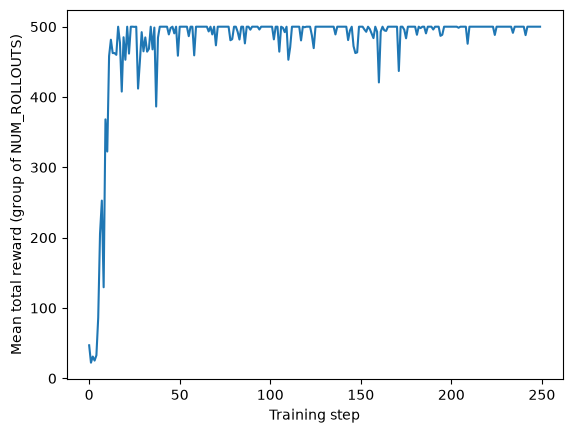

In [25]:
plt.plot(total_rewards)
plt.xlabel('Training step')
plt.ylabel('Mean total reward (group of NUM_ROLLOUTS)');

### 1 Stochastic Sweep 

In [ ]:
# num_samples=32
# num_steps=32

# theta1_vals_viz = np.linspace(-180/np.pi, 180/np.pi, num_steps)
# theta2_vals_viz = np.linspace(-180/np.pi, 180/np.pi, num_steps) 

# all_rewards=[]

# for t1 in tqdm(theta1_vals_viz):
#     all_rewards.append([])
#     for t2 in theta2_vals_viz:
#         all_rewards[-1].append([])
#         for i in range(num_samples):
#             pi = Pi()
#             pi.theta=nn.Parameter(torch.tensor([t1.item(), t2.item()]))
#             states, actions, rewards = run_rollout(seed=i, deterministic=False) 
#             all_rewards[-1][-1].append(np.sum(rewards).item())
# all_rewards=np.array(all_rewards)

In [26]:
# Load from disk
all_rewards = np.load(HACKIN_DIR+'/256_100_sto_2.npy')

In [27]:
avg_reward=np.mean(all_rewards, 2)
std_reward=np.std(all_rewards, 2)

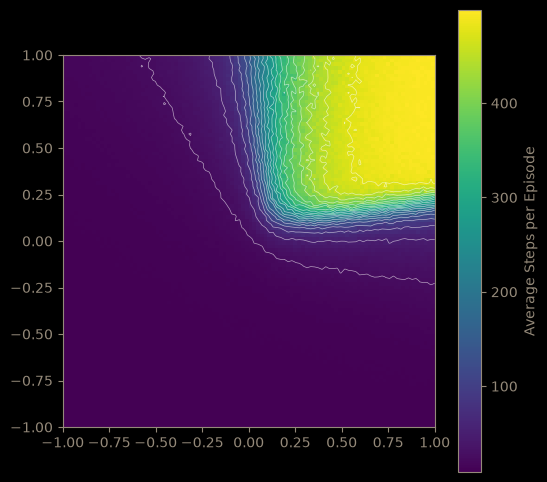

In [28]:
num_steps=all_rewards.shape[0]
theta1_vals_viz = np.linspace(-180/np.pi, 180/np.pi, num_steps)
theta2_vals_viz = np.linspace(-180/np.pi, 180/np.pi, num_steps) 

fig=plt.figure(0, (6,6), facecolor='k')
ax=fig.add_subplot(111)
extent=np.array([theta1_vals_viz[0], theta1_vals_viz[-1], theta2_vals_viz[0], theta2_vals_viz[-1]])
# im = ax.imshow(np.log(avg_reward.T), origin='lower', cmap='viridis',extent=np.radians(extent), aspect='equal') 
im = ax.imshow(avg_reward.T, origin='lower', cmap='viridis',extent=np.radians(extent), aspect='equal') 
T1, T2 = np.meshgrid(np.radians(theta1_vals_viz), np.radians(theta2_vals_viz))
cs = ax.contour(T1, T2, avg_reward.T, levels=20, colors='w', linewidths=0.5, alpha=0.6)
cb = fig.colorbar(im, ax=ax)
style_ax(ax)
cb.set_label('Average Steps per Episode', color=CHILL_BROWN)
cb.ax.yaxis.set_tick_params(color=CHILL_BROWN)
plt.setp(cb.ax.get_yticklabels(), color=CHILL_BROWN)
cb.outline.set_edgecolor(CHILL_BROWN)
plt.savefig(HACKIN_DIR+'/return_landscape_stochastic_3.png', dpi=240)

## 2. Training Animation - GRPO


- Same two-panel training animation as slides_rl_4, but with GRPO instead of vanilla REINFORCE
- Each training step samples NUM_ROLLOUTS episodes from the same policy, then weights each rollout by its group-relative advantage A_i = (R_i - mean R) / std R
- Left panel: parameter space -- return landscape, per-step gradient arrow, thin line following learning
- Right panel: all rollouts in the group, colored by advantage (yellow = above group mean, red = below); per-rollout returns and advantages listed at right
- Should be able to use training configuration above

In [29]:
t1, t2 = -0.5, 0.00 #Starting point

In [30]:
#This is the style I want to use to show trajectories in parameter space. 

# k=66

# fig=plt.figure(0, (6, 6), facecolor='k')
# ax=fig.add_subplot(111, facecolor='k')

# ep=eps[k]
# obs_e, act_e = ep['obs'], ep['act']
# ang, angvel = np.degrees(obs_e[:, 2]), np.degrees(obs_e[:, 3])
# A, V = np.meshgrid(np.linspace(*ANG_LIM, 160), np.linspace(*VEL_LIM, 160))
# P_right_grid = 1 / (1 + np.exp(-(t1 * A + t2 * V)))
# ax.imshow(P_right_grid, origin='lower', cmap=cmap, vmin=0, vmax=1,
#           extent=[*ANG_LIM, *VEL_LIM], aspect='auto', alpha=0.4)
# ax.contour(A, V, P_right_grid, levels=[0.5], colors='w', linestyles='--', linewidths=1.5)
# ax.plot(ang, angvel, color='w', lw=1.0, alpha=0.25, zorder=3, solid_capstyle='round')
# m = act_e == 1
# ax.scatter(ang[m],  angvel[m],  marker=RIGHT_ARROW, s=600, color=YELLOW, alpha=0.85, linewidths=0, zorder=4)
# ax.scatter(ang[~m], angvel[~m], marker=LEFT_ARROW,  s=600, color=BLUE,   alpha=0.85, linewidths=0, zorder=4)
# made_it = len(act_e) == 500
# ax.scatter([ang[-1]], [angvel[-1]],
#            marker=(RIGHT_ARROW if act_e[-1]==1 else LEFT_ARROW), s=600,
#            facecolors='none', edgecolors=('w' if made_it else RED), linewidths=2.5, zorder=5)
# ax.text(0.02, 0.97, f'Steps = {len(act_e)}', transform=ax.transAxes,
#         ha='left', va='top', color='w', fontsize=20)
# ax.set_xlim(*ANG_LIM); ax.set_ylim(*VEL_LIM)
# # ax.set_xlabel('pole angle (degrees)'); ax.set_ylabel('pole angular velocity')
# # ax.set_title('State Space'); 
# style_ax(ax)
# plt.axis('off')
# plt.title(ep['prob'])

In [31]:
# %% ---- Cell A: instrumented GRPO training run ----
# ---- instrumented GRPO run from (t1, t2) ----
# t1, t2 are display coords (same units as the section-1 landscape extent);
# Pi is the radians-native version, so theta_native = np.degrees([t1, t2]).
# Each step: sample NUM_ROLLOUTS episodes, compute group-relative advantages
# A_i = (R_i - mean R) / std R, then one SGD step on
#     loss = -(1/G) * sum_i A_i * sum_t log pi(a_t | s_t)
# Note: once every rollout in a group hits 500, std -> 0 and all advantages
# vanish -> the update is (correctly) zero, hence the stop rule below.
LR = 20
MAX_STEPS = 400
STOP_AFTER_ALL_500 = 5   # a few victory laps after the first all-500 group, then stop

torch.manual_seed(52)
np.random.seed(52)
pi = Pi()
with torch.no_grad():
    pi.theta = nn.Parameter(torch.tensor(np.degrees([t1, t2])).float())
optimizer = optim.SGD(pi.parameters(), lr=LR)

hist = []
first_all_500 = None
for step in tqdm(range(MAX_STEPS)):
    theta_before = pi.theta.detach().numpy().copy()

    # --- collect the group ---
    rollouts = []
    for i in range(NUM_ROLLOUTS):
        states, actions, rewards = run_rollout(seed=step * NUM_ROLLOUTS + i)
        rollouts.append({'obs': np.array(states), 'act': np.array(actions),
                         'R': float(np.sum(rewards))})

    Rs = np.array([r['R'] for r in rollouts], dtype=np.float32)
    advs = (Rs - Rs.mean()) / (Rs.std() + 1e-8)

    # --- GRPO update ---
    loss = 0.0
    for r, A in zip(rollouts, advs):
        T = len(r['act'])
        state_batch = torch.tensor(r['obs'].astype(np.float32))
        action_batch = torch.tensor(r['act'])
        act_probs = pi(state_batch)[torch.arange(T), action_batch]
        r['log_prob'] = torch.log(act_probs).sum().item()
        loss = loss - torch.log(act_probs).sum() * A
    loss = loss / NUM_ROLLOUTS

    optimizer.zero_grad()
    loss.backward()
    grad = pi.theta.grad.detach().numpy().copy()   # dLoss/dtheta (native units)
    optimizer.step()

    hist.append({'rollouts': rollouts, 'Rs': Rs, 'advs': advs,
                 'R_mean': float(Rs.mean()), 'R_std': float(Rs.std()),
                 'theta': np.radians(theta_before),   # display coords, policy that PLAYED this group
                 'grad': grad})

    if first_all_500 is None and Rs.min() == 500:
        first_all_500 = step
    if first_all_500 is not None and step >= first_all_500 + STOP_AFTER_ALL_500:
        break

R_hist = np.array([h['R_mean'] for h in hist])
traj_disp = np.array([h['theta'] for h in hist] + [np.radians(pi.theta.detach().numpy())])
print(f'{len(hist)} steps ({len(hist) * NUM_ROLLOUTS} episodes) | first all-500 group @ {first_all_500} | '
      f'traj t1 [{traj_disp[:,0].min():+.2f}, {traj_disp[:,0].max():+.2f}] '
      f't2 [{traj_disp[:,1].min():+.2f}, {traj_disp[:,1].max():+.2f}]')

 11%|███▉                                | 44/400 [00:00<00:06, 57.10it/s]

45 steps (180 episodes) | first all-500 group @ 39 | traj t1 [-0.50, +0.44] t2 [+0.00, +0.57]


In [ ]:
# hist

In [32]:
# %% ---- Cell B: landscape precompute (reuses section-1 all_rewards) ----
# ---- landscape from section 1, same names/convention as the sweep plot cell ----
num_steps = all_rewards.shape[0]
theta1_vals_viz = np.linspace(-180/np.pi, 180/np.pi, num_steps)
theta2_vals_viz = np.linspace(-180/np.pi, 180/np.pi, num_steps)
extent = np.array([theta1_vals_viz[0], theta1_vals_viz[-1], theta2_vals_viz[0], theta2_vals_viz[-1]])
T1, T2 = np.meshgrid(np.radians(theta1_vals_viz), np.radians(theta2_vals_viz))
A, V = np.meshgrid(np.linspace(*ANG_LIM, 160), np.linspace(*VEL_LIM, 160))


|grad| = 0.08881665  mean R = 18.75


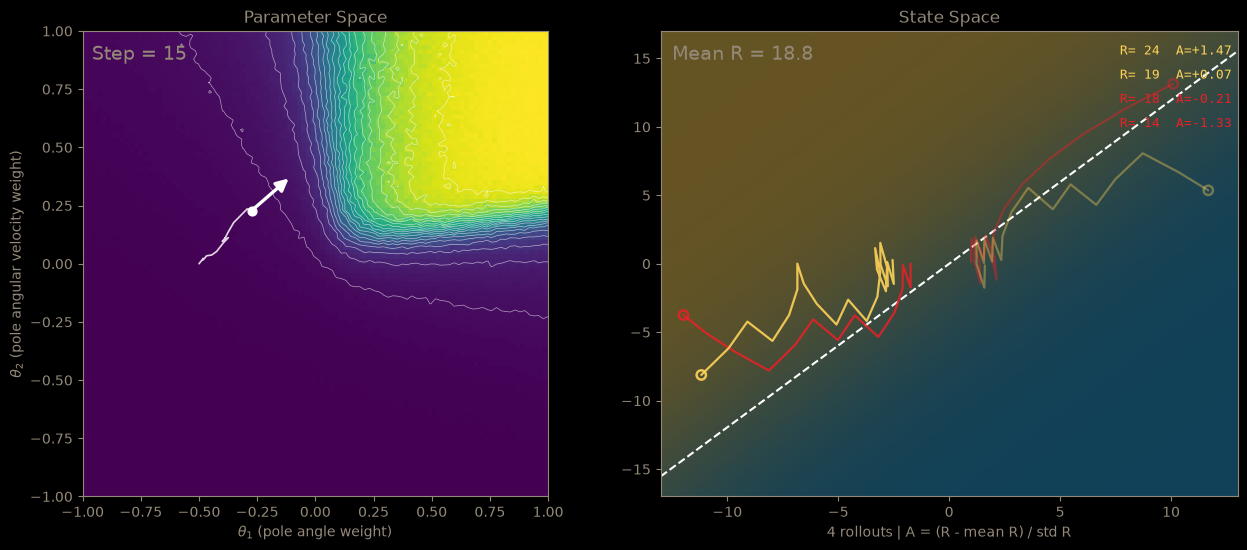

In [34]:
# %% ---- Cell C: single frame -- tweak here before the big loop ----
# ---- single frame: poke around with step_num before running the big loop ----
# step_num = len(hist)-1
step_num = 15
viz_scale = 2.5      # GRPO grads are O(1)-O(10s) native (normalized advantages) -> bigger scale than slides_rl_4
min_draw_len = 0.15
max_draw_len = 0.6
ARROW_HISTORY = 0      # faded arrows for the last few steps; 0 for current-only

ep = hist[step_num]
th1, th2 = ep['theta']

fig, (axL, axR) = plt.subplots(1, 2, figsize=(13, 5.6), facecolor='k')
axL.set_facecolor('k'); axR.set_facecolor('k')

# ---- left: parameter space -- return landscape + grad arrow + learning path ----
im = axL.imshow(avg_reward.T, origin='lower', cmap='viridis', extent=np.radians(extent), aspect='equal')
axL.contour(T1, T2, avg_reward.T, levels=20, colors='w', linewidths=0.5, alpha=0.6)

axL.plot(traj_disp[:step_num+1, 0], traj_disp[:step_num+1, 1],
         color='w', lw=1.2, alpha=0.85, zorder=4, solid_capstyle='round')

for j in range(max(0, step_num-ARROW_HISTORY), step_num+1):
    h = hist[j]
    g = -h['grad']                                   # descent direction (display dir == native dir)
    n = np.linalg.norm(g)
    if n < 1e-12: continue
    g_draw = (g/n) * np.clip(viz_scale*n, min_draw_len, max_draw_len)
    a = 1.0 if j == step_num else 0.25
    axL.annotate('', xy=h['theta'] + g_draw, xytext=h['theta'],
                 arrowprops=dict(arrowstyle='-|>', color='w', lw=2.4, alpha=a, mutation_scale=18))

axL.scatter([th1], [th2], c='w', s=40, zorder=5)
axL.text(0.02, 0.97, f'Step = {step_num}', transform=axL.transAxes,
         ha='left', va='top', color=CHILL_BROWN, fontsize=14)
axL.set_xlabel(r'$\theta_1$ (pole angle weight)')
axL.set_ylabel(r'$\theta_2$ (pole angular velocity weight)')
axL.set_title('Parameter Space'); style_ax(axL)

# ---- right: state space -- the whole group under the policy that played it ----
P_right_grid = 1 / (1 + np.exp(-(th1 * A + th2 * V)))
axR.imshow(P_right_grid, origin='lower', cmap=cmap, vmin=0, vmax=1,
           extent=[*ANG_LIM, *VEL_LIM], aspect='auto', alpha=0.4)
axR.contour(A, V, P_right_grid, levels=[0.5], colors='w', linestyles='--', linewidths=1.5)

order = np.argsort(ep['advs'])                       # most negative first -> best drawn on top
adv_abs_max = max(np.abs(ep['advs']).max(), 1e-8)
for i in order:
    r = ep['rollouts'][i]; Ai = ep['advs'][i]
    ang, angvel = np.degrees(r['obs'][:, 2]), np.degrees(r['obs'][:, 3])
    c = YELLOW if Ai >= 0 else RED
    alpha = 0.35 + 0.55 * abs(Ai) / adv_abs_max      # confident advantages pop, near-mean fade
    axR.plot(ang, angvel, color=c, lw=1.6, alpha=alpha, zorder=4, solid_capstyle='round')
    made_it = len(r['act']) == 500
    axR.scatter([ang[-1]], [angvel[-1]], s=45, facecolors='none',
                edgecolors=('w' if made_it else c), linewidths=1.8, alpha=alpha, zorder=5)

# per-rollout returns + advantages, best at top
for k, i in enumerate(order[::-1]):
    axR.text(0.99, 0.97 - 0.052*k, f"R={ep['Rs'][i]:3.0f}  A={ep['advs'][i]:+.2f}",
             transform=axR.transAxes, ha='right', va='top',
             color=(YELLOW if ep['advs'][i] >= 0 else RED), fontsize=9, family='monospace')

axR.text(0.02, 0.97, f"Mean R = {ep['R_mean']:.1f}", transform=axR.transAxes,
         ha='left', va='top', color=CHILL_BROWN, fontsize=14)
axR.set_xlim(*ANG_LIM); axR.set_ylim(*VEL_LIM)
style_ax(axR)
axR.set_xlabel(f"{NUM_ROLLOUTS} rollouts | A = (R - mean R) / std R", color=CHILL_BROWN)
axR.set_title('State Space')

plt.tight_layout()
print('|grad| =', np.linalg.norm(ep['grad']), ' mean R =', ep['R_mean'])

In [35]:
save_dir = HACKIN_DIR + '/rl_training_grpo'
os.makedirs(save_dir, exist_ok=True)


# %% ---- render every step of the GRPO run ----
for step_num in tqdm(range(len(hist))):
    viz_scale = 2.5      # GRPO grads are O(1)-O(10s) native (normalized advantages) -> bigger scale than slides_rl_4
    min_draw_len = 0.15
    max_draw_len = 0.6
    ARROW_HISTORY = 0      # faded arrows for the last few steps; 0 for current-only

    plt.clf()
    ep = hist[step_num]
    th1, th2 = ep['theta']

    fig, (axL, axR) = plt.subplots(1, 2, figsize=(13, 5.6), facecolor='k')
    axL.set_facecolor('k'); axR.set_facecolor('k')

    # ---- left: parameter space -- return landscape + grad arrow + learning path ----
    im = axL.imshow(avg_reward.T, origin='lower', cmap='viridis', extent=np.radians(extent), aspect='equal')
    axL.contour(T1, T2, avg_reward.T, levels=20, colors='w', linewidths=0.5, alpha=0.6)

    axL.plot(traj_disp[:step_num+1, 0], traj_disp[:step_num+1, 1],
             color='w', lw=1.2, alpha=0.85, zorder=4, solid_capstyle='round')

    for j in range(max(0, step_num-ARROW_HISTORY), step_num+1):
        h = hist[j]
        g = -h['grad']                                   # descent direction (display dir == native dir)
        n = np.linalg.norm(g)
        if n < 1e-12: continue
        g_draw = (g/n) * np.clip(viz_scale*n, min_draw_len, max_draw_len)
        a = 1.0 if j == step_num else 0.25
        axL.annotate('', xy=h['theta'] + g_draw, xytext=h['theta'],
                     arrowprops=dict(arrowstyle='-|>', color='w', lw=2.4, alpha=a, mutation_scale=18))

    axL.scatter([th1], [th2], c='w', s=40, zorder=5)
    axL.text(0.02, 0.97, f'Step = {step_num}', transform=axL.transAxes,
             ha='left', va='top', color=CHILL_BROWN, fontsize=14)
    axL.set_xlabel(r'$\theta_1$ (pole angle weight)')
    axL.set_ylabel(r'$\theta_2$ (pole angular velocity weight)')
    axL.set_title('Parameter Space'); style_ax(axL)

    # ---- right: state space -- the whole group under the policy that played it ----
    P_right_grid = 1 / (1 + np.exp(-(th1 * A + th2 * V)))
    axR.imshow(P_right_grid, origin='lower', cmap=cmap, vmin=0, vmax=1,
               extent=[*ANG_LIM, *VEL_LIM], aspect='auto', alpha=0.4)
    axR.contour(A, V, P_right_grid, levels=[0.5], colors='w', linestyles='--', linewidths=1.5)

    order = np.argsort(ep['advs'])                       # most negative first -> best drawn on top
    adv_abs_max = max(np.abs(ep['advs']).max(), 1e-8)
    for i in order:
        r = ep['rollouts'][i]; Ai = ep['advs'][i]
        ang, angvel = np.degrees(r['obs'][:, 2]), np.degrees(r['obs'][:, 3])
        c = YELLOW if Ai >= 0 else RED
        alpha = 0.35 + 0.55 * abs(Ai) / adv_abs_max      # confident advantages pop, near-mean fade
        axR.plot(ang, angvel, color=c, lw=1.6, alpha=alpha, zorder=4, solid_capstyle='round')
        made_it = len(r['act']) == 500
        axR.scatter([ang[-1]], [angvel[-1]], s=45, facecolors='none',
                    edgecolors=('w' if made_it else c), linewidths=1.8, alpha=alpha, zorder=5)

    # per-rollout returns + advantages, best at top
    for k, i in enumerate(order[::-1]):
        axR.text(0.99, 0.97 - 0.052*k, f"R={ep['Rs'][i]:3.0f}  A={ep['advs'][i]:+.2f}",
                 transform=axR.transAxes, ha='right', va='top',
                 color=(YELLOW if ep['advs'][i] >= 0 else RED), fontsize=9, family='monospace')

    axR.text(0.02, 0.97, f"Mean R = {ep['R_mean']:.1f}", transform=axR.transAxes,
             ha='left', va='top', color=CHILL_BROWN, fontsize=14)
    axR.set_xlim(*ANG_LIM); axR.set_ylim(*VEL_LIM)
    style_ax(axR)
    axR.set_xlabel(f"{NUM_ROLLOUTS} rollouts | A = (R - mean R) / std R", color=CHILL_BROWN)
    axR.set_title('State Space')

    plt.tight_layout()
    plt.savefig(save_dir+'/rl_training_grpo_'+str(step_num).zfill(3)+'.png')
    plt.close(fig)

100%|█████████████████████████████████████| 45/45 [00:11<00:00,  4.03it/s]


<Figure size 640x480 with 0 Axes>

## 4. Visualize Rollout from Trained RL policy

In [ ]:
t1=-0.50 #Swaggin
t2=0.50

# torch.manual_seed(seed)
pi = Pi()

with torch.no_grad(): #
    pi.theta=nn.Parameter(torch.tensor([np.degrees(-t1), np.degrees(t2)]).float()) 

In [ ]:
# ---- roll out the trained policy: 16 episodes from different starting points ----
env = gym.make("CartPole-v1")
out_dim = env.action_space.n

N_EPISODES = 16
DETERMINISTIC = True   # argmax actions, same as the eval histogram above

episodes = []
for seed in range(N_EPISODES):
    states, actions, rewards = run_rollout(seed=seed, deterministic=DETERMINISTIC)
    episodes.append({'obs': np.array(states), 'act': np.array(actions), 'steps': len(rewards)})
    print(f"episode {seed:2d}: {len(rewards):3d} steps" + ("  <- made it to 500!" if len(rewards) == 500 else ""))

print("mean steps:", np.mean([e['steps'] for e in episodes]))

In [ ]:
# ---- quick single-frame check, same layout as section 7 ----
# t1, t2 = traj_plot[-1]   # trained theta from 8.2, in plot (per-degree) units

ep_idx, t = 0, 25
obs_e, act_e = episodes[ep_idx]['obs'], episodes[ep_idx]['act']

fig, (axL, axR) = plt.subplots(1, 2, figsize=(13, 5.6), facecolor='k')
axL.set_facecolor('k'); axR.set_facecolor('k')

ang    = np.degrees(obs_e[:, 2])
angvel = np.degrees(obs_e[:, 3])
m = act_e[:t+1] == 1
a, v = ang[:t+1], angvel[:t+1]

A, V = np.meshgrid(np.linspace(*ANG_LIM, 160), np.linspace(*VEL_LIM, 160))
P_right_grid = 1 / (1 + np.exp(-(t1 * A + t2 * V)))
axL.imshow(P_right_grid, origin='lower', cmap=cmap, vmin=0, vmax=1,
           extent=[*ANG_LIM, *VEL_LIM], aspect='auto', alpha=0.4)
axL.contour(A, V, P_right_grid, levels=[0.5], colors='w', linestyles='--', linewidths=1.5)

axL.scatter(a[m],  v[m],  marker=RIGHT_ARROW, s=180, color=YELLOW, alpha=0.85, linewidths=0)
axL.scatter(a[~m], v[~m], marker=LEFT_ARROW,  s=180, color=BLUE,   alpha=0.85, linewidths=0)

is_terminal = (t == len(act_e)-1)
made_it = episodes[ep_idx]['steps'] == 500
axL.scatter([ang[t]], [angvel[t]],
            marker=(RIGHT_ARROW if act_e[t]==1 else LEFT_ARROW), s=260,
            facecolors='none', edgecolors=(RED if (is_terminal and not made_it) else 'w'),
            linewidths=1.6, zorder=5)

axL.set_xlim(*ANG_LIM); axL.set_ylim(*VEL_LIM)
axL.set_xlabel('pole angle (degrees)'); axL.set_ylabel('pole angular velocity') # (degrees/s / 10)
axL.set_title('State Space'); style_ax(axL)

draw_cartpole(axR, obs_e[t,0], obs_e[t,2], action=act_e[t])
axR.text(0.5, -0.2, f'Step Number = {t}', transform=axR.transAxes,
         ha='center', va='bottom', color=CHILL_BROWN, fontsize=14)
plt.tight_layout()

In [ ]:
save_dir=HACKIN_DIR+'/trained_policy_rl'
os.makedirs(save_dir, exist_ok=True)

def anim_frames(T, dense_steps=40, max_frames=150):
    # every step for the first dense_steps, then evenly-spaced steps so 500-step
    # episodes don't generate thousands of frames -- reads as a fast-forward
    if T <= max_frames:
        return np.arange(T)
    tail = np.linspace(dense_steps, T-1, max_frames - dense_steps).astype(int)
    return np.unique(np.concatenate([np.arange(dense_steps), tail]))

print('total frames ~', sum(len(anim_frames(len(e['act']))) for e in episodes))

In [ ]:
GLOBAL_COUNT=0
PERSIST_EPISODES=False
TERMINAL_HOLD=7
history=[]

for ep_idx, ep in enumerate(tqdm(episodes)):
    obs_e, act_e = ep['obs'], ep['act']
    ang    = np.degrees(obs_e[:, 2])
    angvel = np.degrees(obs_e[:, 3])
    made_it = ep['steps'] == 500

    for t in anim_frames(len(obs_e)):
        fig, (axL, axR) = plt.subplots(1, 2, figsize=(13, 5.6), facecolor='k')
        axL.set_facecolor('k'); axR.set_facecolor('k')

        if PERSIST_EPISODES:
            for h in history:
                axL.scatter(h['a'][h['m']],  h['v'][h['m']],  marker=RIGHT_ARROW, s=180, color=YELLOW, alpha=0.3, linewidths=0)
                axL.scatter(h['a'][~h['m']], h['v'][~h['m']], marker=LEFT_ARROW,  s=180, color=BLUE,   alpha=0.3, linewidths=0)

        m = act_e[:t+1] == 1
        a, v = ang[:t+1], angvel[:t+1]

        A, V = np.meshgrid(np.linspace(*ANG_LIM, 160), np.linspace(*VEL_LIM, 160))
        P_right_grid = 1 / (1 + np.exp(-(t1 * A + t2 * V)))
        axL.imshow(P_right_grid, origin='lower', cmap=cmap, vmin=0, vmax=1,
                   extent=[*ANG_LIM, *VEL_LIM], aspect='auto', alpha=0.4)
        axL.contour(A, V, P_right_grid, levels=[0.5], colors='w', linestyles='--', linewidths=1.5)

        axL.scatter(a[m],  v[m],  marker=RIGHT_ARROW, s=180, color=YELLOW, alpha=0.85, linewidths=0)
        axL.scatter(a[~m], v[~m], marker=LEFT_ARROW,  s=180, color=BLUE,   alpha=0.85, linewidths=0)

        is_terminal = (t == len(act_e)-1)
        ring_color = RED if (is_terminal and not made_it) else 'w'   # red ring only on actual failure -- hitting 500 is a win!
        axL.scatter([ang[t]], [angvel[t]],
                    marker=(RIGHT_ARROW if act_e[t]==1 else LEFT_ARROW), s=260,
                    facecolors='none', edgecolors=ring_color,
                    linewidths=1.6, zorder=5)

        axL.set_xlim(*ANG_LIM); axL.set_ylim(*VEL_LIM)
        axL.set_xlabel('pole angle (degrees)'); axL.set_ylabel('pole angular velocity') # (degrees/s / 10)
        axL.set_title('State Space'); style_ax(axL)

        draw_cartpole(axR, obs_e[t,0], obs_e[t,2], action=act_e[t])
        axR.text(0.5, -0.2, f'Step Number = {t}', transform=axR.transAxes,
                 ha='center', va='bottom', color=CHILL_BROWN, fontsize=14)
        axR.text(0.5, 1.02, f'Episode {ep_idx+1}/{len(episodes)}', transform=axR.transAxes,
                 ha='center', va='bottom', color=CHILL_BROWN, fontsize=14)
        plt.tight_layout()

        plt.savefig(save_dir+'/'+(str(GLOBAL_COUNT).zfill(4)+'.png'), dpi=240, facecolor='k')
        GLOBAL_COUNT+=1
        if is_terminal:
            for k in range(TERMINAL_HOLD):
                plt.savefig(save_dir+'/'+(str(GLOBAL_COUNT).zfill(4)+'.png'), dpi=240, facecolor='k')
                GLOBAL_COUNT+=1
        plt.close(fig)

    if PERSIST_EPISODES:
        history.append({'a': ang, 'v': angvel, 'm': act_e == 1})

In [ ]:
# ---- eval histogram: 256 deterministic rollouts of the pranav-trained policy ----
env = gym.make("CartPole-v1")
out_dim = env.action_space.n

rewardz=[]
for i in range(256):
    states, actions, rewards=run_rollout(seed=i, deterministic=True)
    rewardz.append(np.sum(rewards))

fig, ax = plt.subplots(num=0, figsize=(5,2), facecolor='k')
ax.set_facecolor('k')
ax.hist(rewardz, 20, color=BLUE)
ax.set_title('Average steps = ' + str(round(np.mean(rewardz), 2)))
ax.set_xlabel('Episode steps'); ax.set_ylabel('count')
style_ax(ax)   # CHILL_BROWN spines, ticks, labels, title
plt.savefig('agent_rl_hist.png', dpi=240)